# Three models, one dataset

Some houses, and three models that learn something different about them:

| model | predicts | kind of job |
|---|---|---|
| **Linear regression** | price in dollars | regression |
| **Decision tree** | which tier the house is (trailer → mansion) | classification |
| **Neural network** | price in dollars | regression |

For each one: **look at the data → split it → train → check the metrics → look at the
predictions**, plus one picture of what that model actually learned.

Needs: `numpy`, `pandas`, `matplotlib`, `scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, r2_score, accuracy_score,
                             ConfusionMatrixDisplay, classification_report)

try:
    from sklearn.metrics import root_mean_squared_error as rmse
except ImportError:                                   # sklearn < 1.4
    from sklearn.metrics import mean_squared_error
    def rmse(a, b): return mean_squared_error(a, b) ** 0.5

SEED = 7
INK, TEAL, ACCENT, BLUE, GRAY = "#14202B", "#0E7C86", "#FF6B35", "#1F6E9C", "#9AA8B4"
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.color": "#EAEFF2", "axes.edgecolor": "#C3CCD4",
                     "axes.titleweight": "bold", "legend.frameon": False})
money = FuncFormatter(lambda v, _: f"${v/1000:,.0f}k")

## 1. The data

We make the houses up so we know the right answers. Three features — square footage, bedrooms,
and age — and two things to predict.

**Price** is built from a straight-line rule plus noise:

`price = 118·sqft + 6400·bedrooms − 1250·age + 38000 + noise`

**Tier** is built from rules, the way an estate agent would actually describe a house:

| tier | rule |
|---|---|
| mansion | 2,500+ sq ft **and** 4+ bedrooms |
| luxury | 2,200+ sq ft |
| family | 1,500+ sq ft |
| starter | 1,000+ sq ft and under 50 years old |
| trailer | anything smaller, or small and old |

In [2]:
rng = np.random.default_rng(SEED)
n = 600

sqft = rng.normal(1900, 650, n).clip(600, 4000).round(0)
beds = rng.integers(1, 6, n).astype(float)
age = rng.integers(0, 70, n).astype(float)

price = (38_000 + 118 * sqft + 6_400 * beds - 1_250 * age + rng.normal(0, 15_000, n)).round(0)

TIERS = ["trailer", "starter", "family", "luxury", "mansion"]
TIER_COLORS = ["#C0392B", "#FF6B35", "#E8B21A", "#0E7C86", "#7D4E9E"]

def tier_of(sq, bd, ag):
    if sq >= 2500 and bd >= 4:   return "mansion"
    if sq >= 2200:               return "luxury"
    if sq >= 1500:               return "family"
    if sq >= 1000 and ag < 50:   return "starter"
    return "trailer"

# A little jitter on the size used for labelling, so the tier boundaries come out slightly fuzzy
# instead of perfectly crisp. Otherwise the tree could score 100% and prove nothing.
sqft_fuzzy = sqft + rng.normal(0, 90, n)
tier = np.array([tier_of(s, b, a) for s, b, a in zip(sqft_fuzzy, beds, age)])

df = pd.DataFrame({"sqft": sqft, "beds": beds, "age": age, "price": price, "tier": tier})
FEATURES = ["sqft", "beds", "age"]

print(df.shape)
df.head()

(600, 5)


     sqft  beds   age     price     tier
0  1901.0   2.0  67.0  183152.0   family
1  2094.0   5.0  55.0  251747.0   family
2  1722.0   1.0  18.0  234707.0   family
3  1321.0   3.0  31.0  187780.0  starter
4  1604.0   2.0  45.0  176376.0  starter

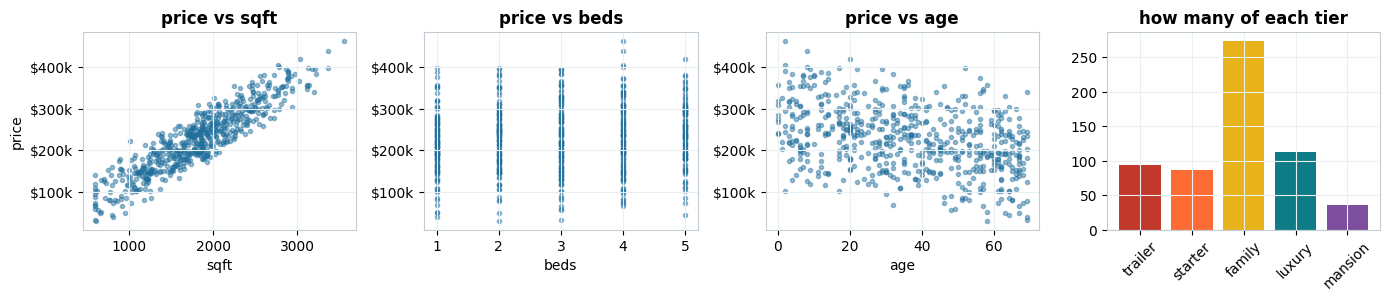

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.1))
for ax, f in zip(axes, FEATURES):
    ax.scatter(df[f], df.price, s=9, alpha=0.45, color=BLUE)
    ax.set_xlabel(f)
    ax.yaxis.set_major_formatter(money)
    ax.set_title(f"price vs {f}")
axes[0].set_ylabel("price")

counts = df.tier.value_counts().reindex(TIERS)
axes[3].bar(counts.index, counts.values, color=TIER_COLORS)
axes[3].set_title("how many of each tier")
axes[3].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Price climbs with square footage, climbs with bedrooms, falls with age — all roughly straight
lines, which is good news for a linear model. The tiers come out unevenly sized, exactly like a
real housing market: lots of family homes, very few mansions.

## 2. Split the data

75% to train on, 25% held back. Scoring a model on houses it already memorised tells you
nothing, so the test set stays sealed until we grade.

`stratify=t` keeps the rare tiers (mansion, trailer) in both halves in the same proportion —
otherwise a random split could leave almost no mansions to test on.

In [4]:
X = df[FEATURES].to_numpy()
y = df.price.to_numpy()
t = df.tier.to_numpy()

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, t, test_size=0.25, random_state=SEED, stratify=t)

print(f"train: {len(X_train)} houses")
print(f"test:  {len(X_test)} houses")

train: 450 houses
test:  150 houses


## 3. How we'll grade each model

**For price (regression):**

* **MAE** — average miss, in dollars. The easy one to explain.
* **RMSE** — same units, but big misses count for more.
* **R²** — share of the variation explained. 1.0 is perfect, 0.0 is no better than guessing the average.

**For tier (classification):** plain **accuracy** — what fraction did it get right.

In [5]:
results = {}

def report(name, y_pred):
    """Print the three regression metrics and remember them."""
    results[name] = {"MAE": mean_absolute_error(y_test, y_pred),
                     "RMSE": rmse(y_test, y_pred),
                     "R2": r2_score(y_test, y_pred)}
    r = results[name]
    print(f"{name}:  MAE ${r['MAE']:,.0f}   RMSE ${r['RMSE']:,.0f}   R² {r['R2']:.3f}")

def plot_predictions(name, y_pred):
    """Predicted price against the real price. The diagonal is a perfect model."""
    lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    fig, ax = plt.subplots(figsize=(4.4, 4.2))
    ax.plot([lo, hi], [lo, hi], ls="--", color=GRAY, label="perfect prediction")
    ax.scatter(y_test, y_pred, s=16, alpha=0.6, color=ACCENT)
    ax.set_xlabel("actual price"); ax.set_ylabel("predicted price")
    ax.xaxis.set_major_formatter(money); ax.yaxis.set_major_formatter(money)
    ax.set_title(f"{name}\non the {len(y_test)} houses it never saw")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. Model 1 — Linear regression → price

Learns one number per feature (a **weight**) plus one offset (the **bias**), then adds them up.

Linear regression:  MAE $12,128   RMSE $15,320   R² 0.962


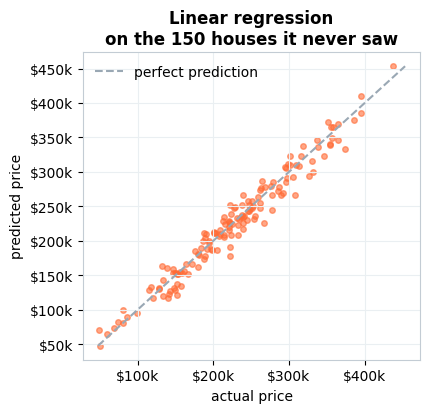

In [6]:
linear = LinearRegression().fit(X_train, y_train)
pred_linear = linear.predict(X_test)

report("Linear regression", pred_linear)
plot_predictions("Linear regression", pred_linear)

### What it learned

Four numbers, and that is the entire model. Since we invented the data, we can check them.

feature  learned  true
   sqft    119.0   118
   beds   6712.0  6400
    age  -1288.0 -1250
   bias  36517.0 38000


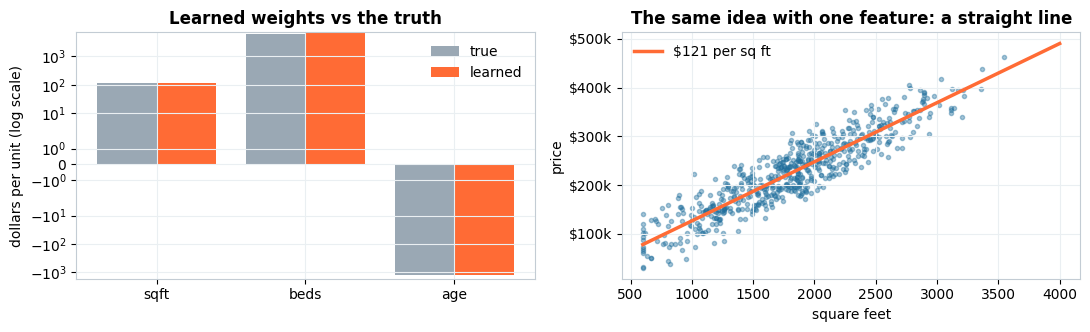

In [7]:
coefs = pd.DataFrame({
    "feature": FEATURES + ["bias"],
    "learned": np.append(linear.coef_, linear.intercept_).round(0),
    "true": [118, 6400, -1250, 38000],
})
print(coefs.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

idx = np.arange(len(FEATURES))
axes[0].bar(idx - 0.2, coefs["true"][:3], 0.4, color=GRAY, label="true")
axes[0].bar(idx + 0.2, coefs["learned"][:3], 0.4, color=ACCENT, label="learned")
axes[0].set_xticks(idx, FEATURES)
axes[0].set_yscale("symlog")
axes[0].set_ylabel("dollars per unit (log scale)")
axes[0].set_title("Learned weights vs the truth")
axes[0].legend()

grid = np.linspace(600, 4000, 100)
axes[1].scatter(df.sqft, df.price, s=9, alpha=0.4, color=BLUE)
one = LinearRegression().fit(X_train[:, [0]], y_train)
axes[1].plot(grid, one.predict(grid.reshape(-1, 1)), color=ACCENT, lw=2.5,
             label=f"${one.coef_[0]:,.0f} per sq ft")
axes[1].set_xlabel("square feet"); axes[1].set_ylabel("price")
axes[1].yaxis.set_major_formatter(money)
axes[1].set_title("The same idea with one feature: a straight line")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Model 2 — Decision tree → tier

Different job: instead of a dollar amount we want a **category**. A tree is a natural fit,
because it learns a chain of yes/no questions — each house follows the answers down to a leaf,
and the leaf holds a tier.

In [8]:
tree = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X_train, t_train)
pred_tree = tree.predict(X_test)

accuracy = accuracy_score(t_test, pred_tree)
print(f"Decision tree accuracy: {accuracy:.1%}  "
      f"({int(round(accuracy * len(t_test)))} of {len(t_test)} right)\n")
print(classification_report(t_test, pred_tree, labels=TIERS, zero_division=0))

Decision tree accuracy: 88.7%  (133 of 150 right)

              precision    recall  f1-score   support

     trailer       0.91      0.88      0.89        24
     starter       0.86      0.90      0.88        21
      family       0.93      0.94      0.93        68
      luxury       0.95      0.71      0.82        28
     mansion       0.60      1.00      0.75         9

    accuracy                           0.89       150
   macro avg       0.85      0.89      0.86       150
weighted avg       0.90      0.89      0.89       150



### Looking at the predictions

For a classifier, the equivalent of the predicted-vs-actual scatter is a **confusion matrix**:
rows are the true tier, columns are what the model guessed. A perfect model puts everything on
the diagonal.

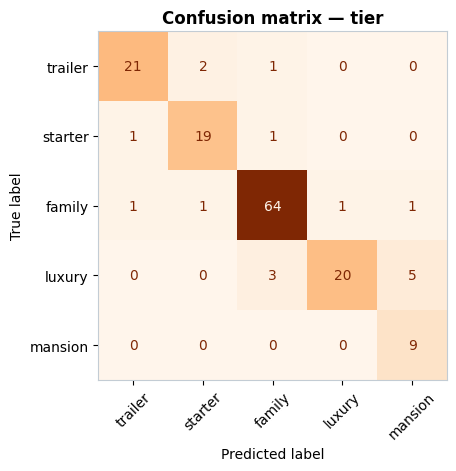

In [9]:
fig, ax = plt.subplots(figsize=(5.4, 4.8))
ConfusionMatrixDisplay.from_predictions(t_test, pred_tree, labels=TIERS,
                                        cmap="Oranges", colorbar=False, ax=ax)
ax.set_title("Confusion matrix — tier")
ax.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The mistakes sit almost entirely **next to** the diagonal — it confuses starter with family, or
luxury with mansion, but it never calls a mansion a trailer. That is the good kind of error.

### What it learned — the actual questions

Every box is a question the algorithm chose by itself. `samples` is how many training houses
reached that box, and `class` is the tier that box predicts.

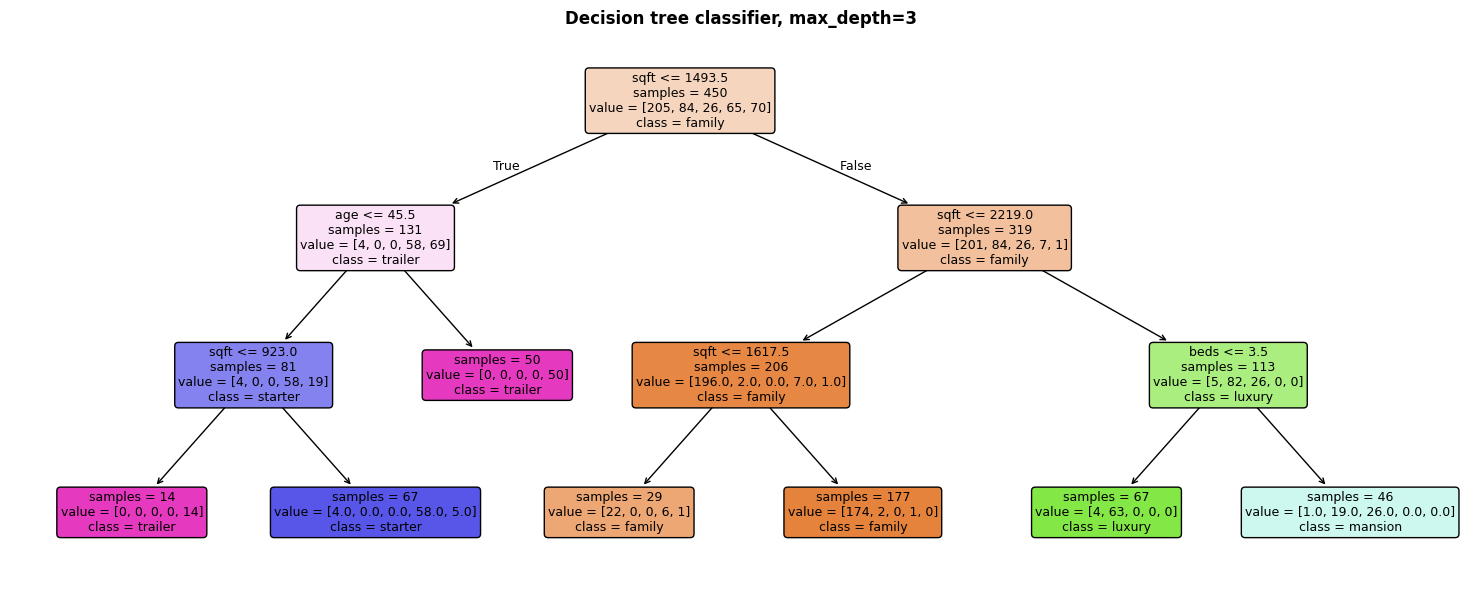

7 leaves

share of the work each feature did:
  sqft    80.2%
  beds     6.4%
  age     13.3%


In [10]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_tree(tree, feature_names=FEATURES, class_names=list(tree.classes_), filled=True,
          rounded=True, impurity=False, precision=1, fontsize=9, ax=ax)
ax.set_title("Decision tree classifier, max_depth=3", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"{tree.get_n_leaves()} leaves\n")
print("share of the work each feature did:")
for f, imp in zip(FEATURES, tree.feature_importances_):
    print(f"  {f:<6} {imp:>6.1%}")

### What it learned — the planes it cut through the data

Every question the tree asks is a **flat cut perpendicular to one axis**. "Is sqft below 2,210?"
is a vertical wall standing at sqft = 2,210. So a tree carves the feature space into rectangular
boxes and predicts one tier per box.

Left: the first two levels of cuts, as planes in 3D. Right: every cut, on a 2D slice through
the cube.

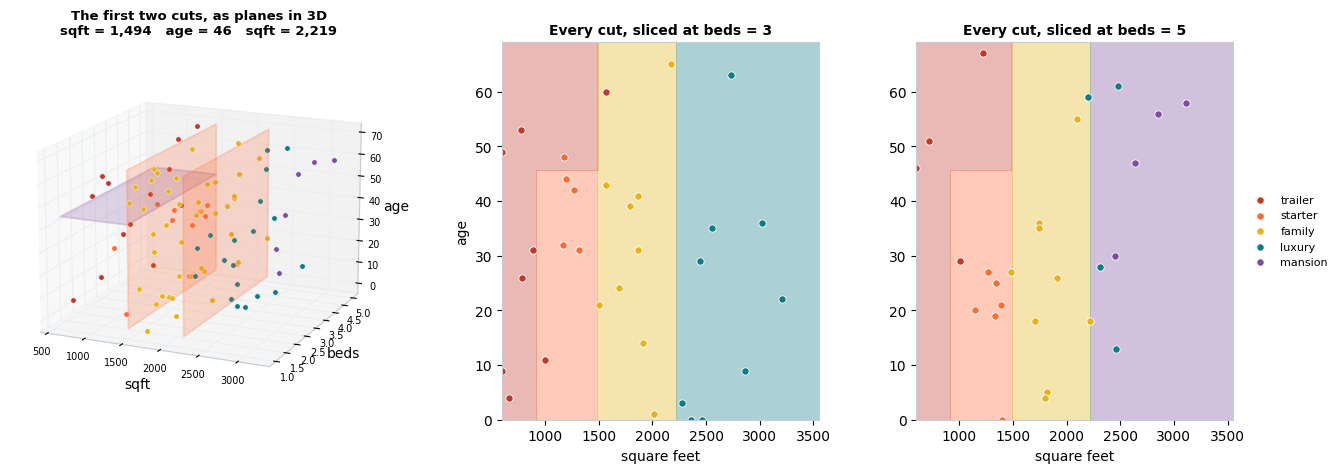

In [11]:
def split_planes(clf, bounds, max_depth):
    """Walk the tree and return (feature, threshold, box) for every internal node.
    Each cut only exists inside its parent's box, which is what makes the picture honest."""
    tr = clf.tree_
    out = []
    def walk(node, box, depth):
        if tr.children_left[node] == -1 or depth > max_depth:
            return
        f, thr = tr.feature[node], tr.threshold[node]
        out.append((f, thr, [b[:] for b in box], depth))
        left = [b[:] for b in box];  left[f] = [box[f][0], thr]
        right = [b[:] for b in box]; right[f] = [thr, box[f][1]]
        walk(tr.children_left[node], left, depth + 1)
        walk(tr.children_right[node], right, depth + 1)
    walk(0, [b[:] for b in bounds], 0)
    return out

bounds = [[X[:, k].min(), X[:, k].max()] for k in range(3)]
FEATURE_COLORS = [ACCENT, TEAL, "#7D4E9E"]

cuts = split_planes(tree, bounds, max_depth=1)

fig = plt.figure(figsize=(16, 4.9))
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1, 1], wspace=0.28)

# ---------- left: the top-level cuts as planes in 3D ----------
ax = fig.add_subplot(gs[0], projection="3d")
for f, thr, box, depth in cuts:
    others = [k for k in range(3) if k != f]
    (u0, u1), (v0, v1) = box[others[0]], box[others[1]]
    corners = []
    for u, v in [(u0, v0), (u1, v0), (u1, v1), (u0, v1)]:
        pt = [0, 0, 0]
        pt[f], pt[others[0]], pt[others[1]] = thr, u, v
        corners.append(pt)
    ax.add_collection3d(Poly3DCollection([corners], facecolor=FEATURE_COLORS[f], alpha=0.22,
                                         edgecolor=FEATURE_COLORS[f], linewidths=1.3))

shown = rng.choice(len(X_test), 90, replace=False)
for tier_name, color in zip(TIERS, TIER_COLORS):
    m = np.zeros(len(X_test), bool)
    m[shown] = True
    m &= (t_test == tier_name)
    ax.scatter(X_test[m, 0], X_test[m, 1], X_test[m, 2], s=15, color=color,
               depthshade=False, edgecolor="white", linewidth=0.3)
ax.set_xlabel("sqft", labelpad=-2); ax.set_ylabel("beds", labelpad=-4)
ax.set_zlabel("age", labelpad=-4)
ax.tick_params(labelsize=7, pad=-1)
ax.view_init(elev=16, azim=-66)
ax.set_title("The first two cuts, as planes in 3D\n"
             + "   ".join(f"{FEATURES[f]} = {thr:,.0f}" for f, thr, _, _ in cuts),
             fontsize=9.5)

# ---------- right: every cut, on two slices through the cube ----------
gsq, gag = np.meshgrid(np.linspace(*bounds[0], 300), np.linspace(*bounds[2], 300))

for panel, slice_beds in enumerate([3, 5]):
    ax2 = fig.add_subplot(gs[panel + 1])
    flat = np.c_[gsq.ravel(), np.full(gsq.size, float(slice_beds)), gag.ravel()]
    zone = np.array([TIERS.index(p) for p in tree.predict(flat)]).reshape(gsq.shape)
    ax2.contourf(gsq, gag, zone, levels=np.arange(-0.5, len(TIERS)),
                 colors=TIER_COLORS, alpha=0.35)
    on_slice = X_test[:, 1] == slice_beds
    for tier_name, color in zip(TIERS, TIER_COLORS):
        m = on_slice & (t_test == tier_name)
        ax2.scatter(X_test[m, 0], X_test[m, 2], s=28, color=color,
                    edgecolor="white", linewidth=0.6, label=tier_name)
    ax2.set_xlabel("square feet")
    ax2.set_ylabel("age" if panel == 0 else "")
    ax2.set_title(f"Every cut, sliced at beds = {slice_beds}", fontsize=10)
    ax2.grid(False)
    if panel == 1:
        ax2.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.show()

The two right-hand panels are the ones to study. Those flat-sided coloured blocks **are** the
model — a tree can only ever produce boxes with axis-parallel walls, one tier per box.

Three things to point out:

* **Top-left corner of either slice.** The tree worked out by itself that a small house which is
  *also* old should be a trailer rather than a starter. That is the `sqft < 1500 and age ≥ 50`
  rule we buried in the data, recovered from nothing but examples.
* **The two slices differ only in bedroom count**, and that single change flips the whole
  top band from luxury to mansion. That is the `beds <= 3.5` question doing its job.
* **Nothing is diagonal.** If the real boundary had been a slanted line, the tree would have had
  to approximate it with a staircase of these boxes. That is the cost of asking about one
  feature at a time.

## 6. Model 3 — Neural network → price

Back to predicting price. A network is a stack of small units, each doing the same weighted sum
as linear regression, then passing the result through a bend (`ReLU`) so the whole thing can curve.

Networks need their numbers in a sane range, so we standardise the inputs *and* the target
before training, then convert the predictions back into dollars.

Neural network:  MAE $12,159   RMSE $15,528   R² 0.961


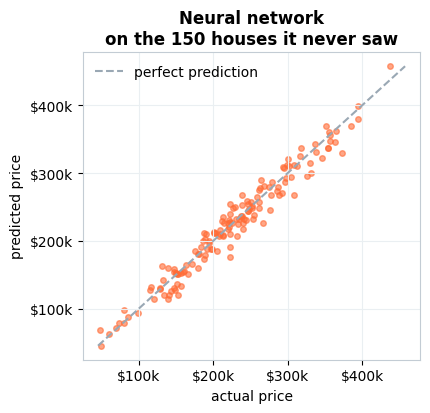

In [12]:
x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))

net = MLPRegressor(hidden_layer_sizes=(4, 3), activation="relu",
                   solver="lbfgs", max_iter=4000, random_state=SEED)
net.fit(x_scaler.transform(X_train), y_scaler.transform(y_train.reshape(-1, 1)).ravel())

scaled_pred = net.predict(x_scaler.transform(X_test)).reshape(-1, 1)
pred_net = y_scaler.inverse_transform(scaled_pred).ravel()

report("Neural network", pred_net)
plot_predictions("Neural network", pred_net)

### What it learned — the neurons and their weights

Each circle is a neuron. Each line is a weight: **orange is positive, teal is negative, and
thicker means bigger**. Those line thicknesses are the entire trained model.

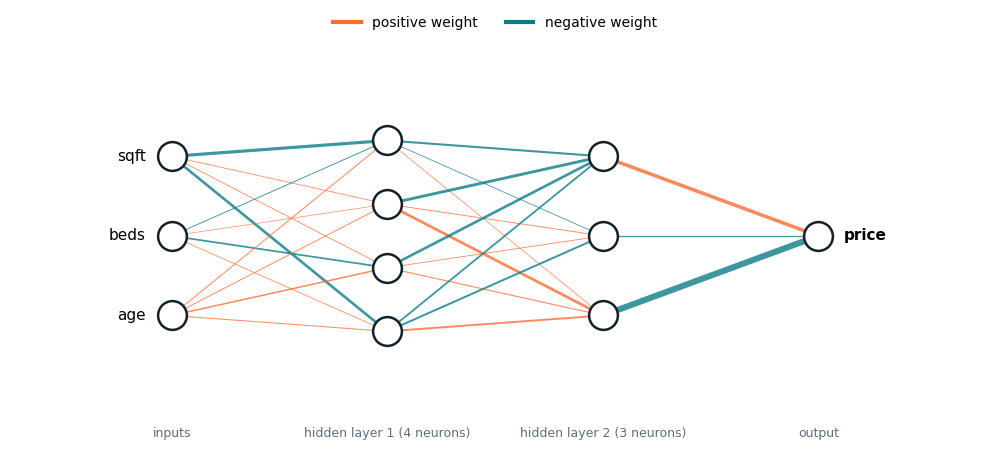

35 numbers in this network, versus 4 for linear regression.

weights into layer 1  3 -> 4
[[-0.96  0.09  0.1  -0.79]
 [-0.14  0.04 -0.44  0.08]
 [ 0.16  0.14  0.36  0.16]] 

weights into layer 2  4 -> 3
[[-0.57 -0.09  0.07]
 [-0.87  0.13  0.81]
 [-0.78  0.1   0.2 ]
 [-0.48 -0.53  0.51]] 

weights into layer 3  3 -> 1
[[ 1.11]
 [-0.26]
 [-2.08]] 



In [13]:
def draw_network(model, input_names, output_name="price"):
    sizes = [model.coefs_[0].shape[0]] + [c.shape[1] for c in model.coefs_]
    xs = np.linspace(0, 1, len(sizes))
    # linspace runs 1 -> 0 so the first input ends up at the top of the picture
    pos = [[(xs[k], yy) for yy in (np.linspace(1, 0, s + 2)[1:-1] if s > 1 else [0.5])]
           for k, s in enumerate(sizes)]
    wmax = max(np.abs(c).max() for c in model.coefs_)

    fig, ax = plt.subplots(figsize=(10, 4.8))
    for k, C in enumerate(model.coefs_):
        for i, (x0, y0) in enumerate(pos[k]):
            for j, (x1, y1) in enumerate(pos[k + 1]):
                w = C[i, j]
                ax.plot([x0, x1], [y0, y1], color=ACCENT if w > 0 else TEAL,
                        lw=0.4 + 4.0 * abs(w) / wmax, alpha=0.8, zorder=1,
                        solid_capstyle="round")
    for layer in pos:
        for (x, yy) in layer:
            ax.scatter([x], [yy], s=430, color="white", edgecolor=INK, lw=1.8, zorder=3)

    for (x, yy), nm in zip(pos[0], input_names):
        ax.text(x - 0.04, yy, nm, ha="right", va="center", fontsize=11)
    ax.text(pos[-1][0][0] + 0.04, pos[-1][0][1], output_name,
            ha="left", va="center", fontsize=11, fontweight="bold")

    captions = ["inputs"] + [f"hidden layer {k} ({s} neurons)"
                             for k, s in enumerate(sizes[1:-1], 1)] + ["output"]
    for x, cap in zip(xs, captions):
        ax.text(x, -0.1, cap, ha="center", va="top", fontsize=9, color="#5D6E7C")

    ax.plot([], [], color=ACCENT, lw=3, label="positive weight")
    ax.plot([], [], color=TEAL, lw=3, label="negative weight")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=2)
    ax.set_xlim(-0.25, 1.25); ax.set_ylim(-0.22, 1.1)
    ax.axis("off"); ax.grid(False)
    plt.tight_layout()
    plt.show()

draw_network(net, FEATURES)

total = sum(c.size for c in net.coefs_) + sum(b.size for b in net.intercepts_)
print(f"{total} numbers in this network, versus {len(FEATURES) + 1} for linear regression.\n")
for k, C in enumerate(net.coefs_):
    print(f"weights into layer {k + 1}  {C.shape[0]} -> {C.shape[1]}")
    print(np.round(C, 2), "\n")

## 7. Side by side

Only the two price models are directly comparable — the tree was doing a different job.

                       MAE     RMSE     R2
Linear regression  12128.0  15320.0  0.962
Neural network     12159.0  15528.0  0.961

Decision tree (tier classification): 88.7% accuracy


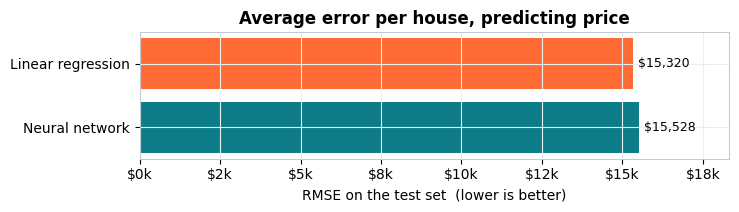

In [14]:
board = pd.DataFrame(results).T.sort_values("RMSE")
print(board.round({"MAE": 0, "RMSE": 0, "R2": 3}).to_string())
print(f"\nDecision tree (tier classification): {accuracy:.1%} accuracy")

fig, ax = plt.subplots(figsize=(7.5, 2.2))
ax.barh(board.index, board.RMSE, color=[ACCENT, TEAL])
ax.invert_yaxis()
ax.set_xlabel("RMSE on the test set  (lower is better)")
ax.xaxis.set_major_formatter(money)
ax.set_title("Average error per house, predicting price")
for name, v in board.RMSE.items():
    ax.text(v * 1.01, name, f"${v:,.0f}", va="center", fontsize=9)
ax.set_xlim(0, board.RMSE.max() * 1.18)
plt.tight_layout()
plt.show()

The two price models land in the same place, because we built price from a straight-line rule and
neither of them can learn the random noise we added on top. The network spends 35 numbers to
match what linear regression does with 4.

**Things to try:**

* Raise the tree's `max_depth` to 5 and re-run. Accuracy goes up, the tree diagram gets much
  busier, and the boxes in the slice plot get smaller.
* Change `SLICE_BEDS` to 2. The mansion region disappears — a 2-bedroom house can never be one.
* Change `hidden_layer_sizes` to `(8, 6)` and redraw the network.
* Drop a feature from `FEATURES` and see which model minds the most.